# Evaluate evoked LFP response by optogenetic stimulations

### Import recordings

Load packages

In [1]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os
from IPython.display import display
from ipyfilechooser import FileChooser
from scipy.stats import zscore
import json
import matplotlib.cm as cm
import IPython
import ast
from scipy.interpolate import interp1d
%matplotlib widget

In [2]:
#Load LFP coordinates 
notebook_path = Path("/".join(IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")[-5:]))
Channels = f'{notebook_path.parent}/_LFP_coordinates_of_all_mice.csv'
all_LFPcoordinates = pd.read_csv(Channels, index_col=0)
all_LFPcoordinates = pd.read_csv('_LFP_coordinates_of_all_mice.csv', sep=';', index_col=0)

Choose OpenEphys folder

In [3]:
try: # tries to retrieve dpath either from a previous run or from a previous notebook
    %store -r dpath
except:
    print("the path was not defined in store")
    dpath = "//10.69.168.1/crnldata/forgetting/"

fc1 = FileChooser(dpath,select_default=True, show_only_dirs = True, title = "<b>Go inside the folder containing the LFP raw file</b>")
display(fc1)

# Sample callback function
def update_my_folder(chooser):
    global dpath
    dpath = chooser.selected
    %store dpath
    return 

# Register callback function
fc1.register_callback(update_my_folder)

FileChooser(path='\\10.69.168.1\crnldata\forgetting\Carla\OpenEphysData\Opto_stim\RH\APPPS1\Male\EtoileBleu\Et…

Load LFPs data, TTL, timestamps

In [88]:
folder_base = Path(dpath) 
miceIDflipped=[]

if Path(f'{folder_base}\DataFrame_rawdataDS.pkl').exists(): # prefer loading downsample file over original file
    print('DataFrame_rawdataDS.pkl file')
    LFPfile = Path(f'{folder_base}\DataFrame_rawdataDS.pkl')
    LFPs_df = pd.read_pickle(LFPfile)
    samplerate = 1000 
    numchannel = LFPs_df.shape[1]
    rec_ch_list = LFPs_df.columns.values
    # Load LFPs timestamps 
    for file_pathTS in folder_base.parent.parent.glob('**/continuous/*/timeStampsDS.npy'):
        print('LFPs timestamps file found')
        LFPtimestamps = np.load(file_pathTS)  
elif Path(f'{folder_base}\continuous.dat').exists():
    print('continuous.dat file')
    LFPfile = Path(f'{folder_base}\continuous.dat')
    DataRec = np.fromfile(LFPfile, dtype="int16")
    filepath = Path(os.path.join(folder_base.parent.parent, f'structure.oebin'))
    with open(filepath) as f:
        metadata = json.load(f)
    samplerate = metadata['continuous'][0]['sample_rate']  
    numchannel = metadata['continuous'][0]['num_channels'] 
    rec_ch_list_origin = np.array([int(''.join(c for c in metadata['continuous'][0]['channels'][x]['channel_name'] if c.isdigit()))-1 for x in range(0, len(metadata['continuous'][0]['channels']))])
    rec_ch_list = np.array([int(''.join(filter(str.isdigit, c['channel_name']))) - 1  for c in metadata['continuous'][0]['channels'] if c['channel_name'].startswith('CH')])
    DataRec = DataRec.reshape(-1,numchannel)
    numchannel = len(rec_ch_list)
    DataRec = DataRec[:,:numchannel]

    print('Metadata found')
    # Load LFPs timestamps 
    for file_pathTS in folder_base.parent.parent.glob('**/continuous/*/timeStamps.npy'):
        print('LFPs timestamps file found')
        LFPtimestamps = np.load(file_pathTS) 
    LFPs_df=pd.DataFrame(DataRec, columns=rec_ch_list) 
else: 
    print('no LFPs file found')

print('sample rate =', samplerate, 'Hz')
print(numchannel, 'channels recorded')
print(round(LFPs_df.shape[0]/samplerate/60), 'min of recording')

continuous.dat file
Metadata found
LFPs timestamps file found
sample rate = 10000.0 Hz
13 channels recorded
11 min of recording


In [90]:
nb_decimal=4 # 4 = 0.1ms precision / 3 = 1ms precision

# Load TTLs
TTL_Opto_duration=[]
for file_pathTTL in folder_base.parent.parent.glob('**/TTL/timeStamps.npy'):
    print('TTL opto file = ', file_pathTTL)
    TTL_Opto_o = np.load(file_pathTTL)
    TTL_Opto_duration =[round(TTL_Opto_o[i+1] - TTL_Opto_o[i],nb_decimal) for i in range(len(TTL_Opto_o) - 1)[::2]]
    TTL_Opto= TTL_Opto_o[::2] # remove the TTL for laser OFF, only keep TTL for laser ON. CAUTION /!/ works only if it started with a TTL for laser ON
    print(TTL_Opto.shape[0], 'opto stimulations')

TTL opto file =  \\10.69.168.1\crnldata\forgetting\Carla\OpenEphysData\Opto_stim\RH\APPPS1\Female\EtoileOrange\EtoileOrange_2026-07-20_16-29-03_StimOpto_3mois\Record Node 101\experiment1\recording1\events\OE_FPGA_Acquisition_Board-100.Rhythm Data\TTL\timeStamps.npy
112 opto stimulations


Downsample LFP data to 1kHz if needed & save it

In [91]:
if samplerate > 1000:
    new_sampling_rate = 1000 # Hz
    Nmber_points = int(np.shape(LFPs_df)[0] * new_sampling_rate / samplerate)
    LFPs_df_DS = pd.DataFrame(signal.resample(LFPs_df, Nmber_points, axis = 0), columns=LFPs_df.columns.values)
    LFPtimestampsDS = LFPtimestamps[::int(samplerate/new_sampling_rate)][:-1]
    samplerate = new_sampling_rate
    LFPs_df_DS.to_pickle(f'{LFPfile.parent}/DataFrame_rawdataDS.pkl')
    np.save(f'{file_pathTS.parent}/timeStampsDS.npy', LFPtimestampsDS)
    LFPs_df = LFPs_df_DS
    LFPtimestamps = LFPtimestampsDS
# eventually delete original files to gain space

Identify LFP electrodes

In [92]:
mouse = []
pos_mice = []
for mouse_name in all_LFPcoordinates.index:
    if mouse_name in LFPfile.__str__():
        mouse.append(mouse_name)
        pos_mice.append(LFPfile.__str__().find(mouse_name)) 
mouse = [x for _, x in sorted(zip(pos_mice, mouse))] # sort mouse in the same order as they appear in the path

if len(mouse) > 1: # found multiple mouse name in the path
    if max(rec_ch_list) <= 31: # no channels superior to 32, so only one mouse recorded
        id = 0 # change to 0 to see the first mouse name found, 1 the second, etc
        ID = 0
        print(f"/!\ Mutliple mice name found in the path but only mouse recorded = {mouse}. The n°{id+1} was choosen automatically = {mouse[id]}.")
        mouse = mouse[id]
    else:
        ###################################################################################################################################
        ID = 1 # choose 0 to see the first mouse recorded, 1 the second, 2 the third, 3 the fourth (only 4 mice can be recorded at the same time)
        ###################################################################################################################################
        print(f"/!\ Mutliple mice recorded at the same time = {mouse}. The n°{ID+1} was choosen automatically = {mouse[ID]}.")
        mouse = mouse[ID] 
elif len(mouse) == 1: # found only one mouse name in the path
    ID = 0
    mouse = mouse[ID]
    
all_LFPcoordinates= all_LFPcoordinates.astype(str)
for region in all_LFPcoordinates.loc[mouse].index:
    locals()[f'{region}_0']=[]
    locals()[f'{region}_1']=[]
    locals()[f'{region}_0ch']=[]
    locals()[f'{region}_1ch']=[]

RecordedArea = []
ChoosenChannels = []
combined = []
if mouse:
    rec_ch_list_mouse = [value for value in rec_ch_list if 0+(ID*32) <= value <= 31+(ID*32)]
    for rec_ch in rec_ch_list_mouse:
        for idx, LFPcoord_str in enumerate(all_LFPcoordinates.loc[mouse]):
            region = all_LFPcoordinates.loc[mouse].index[idx]
            if LFPcoord_str != 'nan' and region != 'EMG':
                LFPcoord = LFPcoord_str.split('_')[:2] # only take into account the 2 first of electrode of that region 
                num_ch = np.where(str(rec_ch-(ID*32)) == np.array(LFPcoord))[0]
                if len(num_ch)>0:
                    region=all_LFPcoordinates.loc[mouse].index[idx]
                    LFP=locals()[f'{region}_0']
                    if len(LFP)>0:
                        LFP= np.array(LFPs_df[(rec_ch)])
                        locals()[f'{region}_1']=LFP
                        locals()[f'{region}_1ch']=rec_ch
                    else:
                        LFP= np.array(LFPs_df[(rec_ch)])
                        locals()[f'{region}_0']=LFP
                        locals()[f'{region}_0ch']=rec_ch
                    break
                continue
    
    for region in all_LFPcoordinates.loc[mouse].index:
        for n in range(0,2,1):
            LFP=locals()[f'{region}_{n}']
            LFP_ch=locals()[f'{region}_{n}ch']
            if len(LFP)>0:
                combined=zscore(LFP[:,np.newaxis]) if len(combined)==0 else np.append(combined, zscore(LFP[:,np.newaxis]), axis=1)
                RecordedArea.append(f'{region}_{n}') 
                ChoosenChannels.append(LFP_ch) 
else:
    print("/!\ No mouse name found in the path OR in the csv file '_LFP_coordinates_of_all_mice.csv'")
    mouse = '' # fill mouse name
    RecordedArea = ['PFC','S1'] 
    PFC_0 = LFPs_df[0]
    S1_1 = LFPs_df[1]
    combined = np.stack([zscore(PFC_0), zscore(S1_1)], axis=1)

print(mouse)
print(RecordedArea)
print(ChoosenChannels) 

EtoileOrange
['S1_0', 'S1_1', 'PFC_0', 'PFC_1', 'CA1_0', 'CA1_1', 'oPFC_0', 'oPFC_1', 'EnthC_0', 'EnthC_1', 'RH_0', 'RH_1']
[18, 19, 20, 21, 14, 15, 22, 23, 12, 13, 16, 17]


Check TTL durations

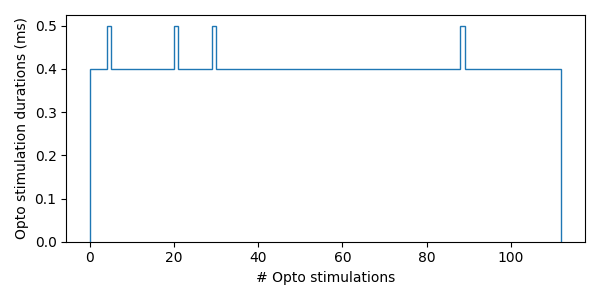

In [94]:
plt.close('all')
plt.figure(figsize=(6, 3))
plt.stairs(np.array(TTL_Opto_duration)*1000)
plt.xlabel('# Opto stimulations')
plt.ylabel('Opto stimulation durations (ms)')
plt.tight_layout()
plt.show()

### Get response of each brain region

AllEPSPs=[]
for ttl in TTL_Opto:   
    idx = (np.abs(LFPtimestamps - ttl)).argmin() # find the closest LFP timestamps to the TTL
    AllEPSPs.append(combined[idx-round(0.5*samplerate):idx+round(0.5*samplerate), :]) #500 ms before and after TTL

plt.close()
plt.figure(figsize=(6, 3))
time_axis = np.linspace(-500, 500, np.shape(AllEPSPs)[1]) 
mEPSPs=np.mean(AllEPSPs, axis=0)
colors = cm.rainbow(np.linspace(0, 1, np.shape(mEPSPs)[1]))
for i in np.arange(0,np.shape(AllEPSPs)[2]):
    plt.plot(time_axis, mEPSPs[:,i], label=f'{RecordedArea[i]}', color=colors[i])
plt.xlabel("Time (ms)")
plt.ylabel("Averaged EPSPs")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncols=1)
plt.subplots_adjust(right=.5)
plt.xlim([-25, 50])
plt.title(f'Mouse = {mouse}, Stim opto duration = {np.unique(TTL_Opto_duration)[0]*1000} - {np.round(np.unique(TTL_Opto_duration)[-1]*1000,2)} ms \nfilename = {folder_base.parts[-6]}', fontsize=12) # Change to indicate where is located that LFP
plt.tight_layout()
plt.show()

### Get response for one brain region

Choose brain region

In [119]:
# === SÉLECTION DE LA RÉGION ===
Selected_region = 'EnthC_0' # to change
SelectedLFP = locals()[Selected_region]



🧠 RÉGION SÉLECTIONNÉE: EnthC_0

Durée de stimulation: 0.4 ms
Nombre total de stimulations: 112

🔍 Analyse de EnthC_0...

  ✓ 111 stimulations valides (sur 112)

📊 AFFICHAGE DU GRAPHIQUE

💡 Cliquez sur 2 points du graphique pour calculer l'aire sous la courbe
   Un 3ème clic réinitialise la sélection.



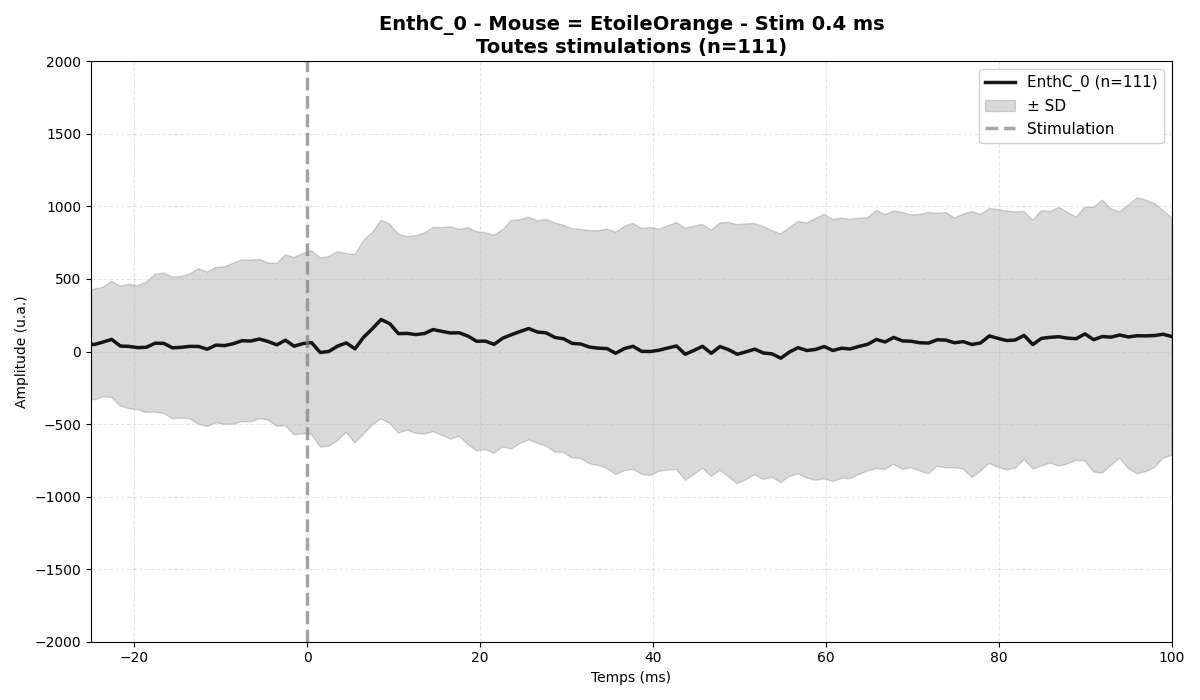

✓ Graphique affiché : EnthC_0

✅ Visualisation complétée pour EnthC_0


In [120]:

print(f"\n{'='*60}")
print(f"🧠 RÉGION SÉLECTIONNÉE: {Selected_region}")
print(f"{'='*60}\n")

# === PARAMÈTRES ===
halfdurEPSP = 0.1  # sec
analyseWindow = 0.025  # sec post-stimulation

stim_duration = np.unique(TTL_Opto_duration)[0] * 1000  # ms
nb_stims = len(TTL_Opto)

print(f"Durée de stimulation: {stim_duration} ms")
print(f"Nombre total de stimulations: {nb_stims}")

# === ANALYSE DE TOUTES LES STIMULATIONS ===
print(f"\n{'='*60}")
print(f"🔍 Analyse de {Selected_region}...")
print(f"{'='*60}\n")

# Extraction des stimulations
all_stim = []
for ttl in TTL_Opto:
    idx = (np.abs(LFPtimestamps - ttl)).argmin()
    stim_signal = SelectedLFP[idx - round(halfdurEPSP * samplerate):
                               idx + round(halfdurEPSP * samplerate)]
    all_stim.append(stim_signal)

all_stim_df = pd.DataFrame(all_stim).T

# Correction de baseline
baseline_window = slice(0, int(halfdurEPSP * samplerate))
corrected_columns = []
for col in all_stim_df.columns:
    baseline_mean = all_stim_df[col][baseline_window].mean()
    corrected_columns.append(all_stim_df[col] - baseline_mean)

all_stim_corrected = pd.concat(corrected_columns, axis=1)
all_stim_corrected.columns = all_stim_df.columns

# Suppression outliers amplitude (≥ 4×SD)
amplitude_temp = []
for col in all_stim_corrected.columns:
    post_stim_start = int(halfdurEPSP * samplerate)
    post_stim_end = int((halfdurEPSP + analyseWindow) * samplerate)
    post_stim_window = all_stim_corrected[col][post_stim_start:post_stim_end]
    amplitude = post_stim_window.max() - post_stim_window.min()
    amplitude_temp.append(amplitude)

amp_array = np.array(amplitude_temp)
amp_mean = np.mean(amp_array)
amp_std = np.std(amp_array)
valid_indices = np.where(amp_array < amp_mean + 4 * amp_std)[0]
all_stim_corrected = all_stim_corrected.iloc[:, valid_indices]
nb_stims_valid = len(valid_indices)

# Calcul de la moyenne et écart-type
mean_signal = all_stim_corrected.mean(axis=1)
std_signal  = all_stim_corrected.std(axis=1)
time_axis   = np.linspace(-halfdurEPSP * 1000, halfdurEPSP * 1000,
                           all_stim_corrected.shape[0])

print(f"  ✓ {nb_stims_valid} stimulations valides (sur {nb_stims})\n")

# === VISUALISATION GRAPHIQUE AVEC SÉLECTION D'AIRE ===
print(f"{'='*60}")
print(f"📊 AFFICHAGE DU GRAPHIQUE")
print(f"{'='*60}\n")
print("💡 Cliquez sur 2 points du graphique pour calculer l'aire sous la courbe")
print("   Un 3ème clic réinitialise la sélection.\n")

fig, ax = plt.subplots(figsize=(12, 7))

# Courbe moyenne + écart-type
ax.plot(time_axis, mean_signal,
        color='#000000', linewidth=2.5,
        label=f'{Selected_region} (n={nb_stims_valid})',
        alpha=0.9)
ax.fill_between(time_axis,
                mean_signal - std_signal,
                mean_signal + std_signal,
                color='#000000', alpha=0.15, label='± SD')

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7,
           linewidth=2.5, label='Stimulation')
ax.set(xlabel="Temps (ms)", ylabel="Amplitude (u.a.)",
       xlim=(-25, 100), ylim=(-2000, 2000))
ax.set_title(f'{Selected_region} - Mouse = {mouse} - Stim {stim_duration:.1f} ms\nToutes stimulations (n={nb_stims_valid})',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# === GESTION DES CLICS : AIRE (clic simple) & PENTE (double-clic) ===
click_state = {'points': [], 'artists': []}   # aire (clic simple)
slope_state = {'points': [], 'artists': []}   # pente (double-clic)

signal_interp = interp1d(time_axis, np.array(mean_signal), kind='linear')


def compute_area(x1, x2, first_x):
    y_ref = float(signal_interp(first_x))
    x_fine = np.linspace(x1, x2, 500)
    y_fine = signal_interp(x_fine)
    baseline_fine = np.full_like(x_fine, y_ref)

    auc     = np.trapz(y_fine - baseline_fine, x_fine)
    auc_abs = np.trapz(np.abs(y_fine - baseline_fine), x_fine)

    fill = ax.fill_between(x_fine, y_fine, baseline_fine,
                           color='#FFD700', alpha=0.50,
                           label=f'AUC = {auc:.1f}')
    click_state['artists'].append(fill)
    print(f"\n{'─'*55}")
    print(f"📐 Aire entre {x1:.2f} ms et {x2:.2f} ms")
    print(f"{'─'*55}")
    print(f"  AUC   = {auc:.4f}")
    print(f"  |AUC| = {auc_abs:.4f}")
    print(f"{'─'*55}\n")


def compute_slope(xa, xb):
    xa, xb = sorted([xa, xb])
    ya, yb = float(signal_interp(xa)), float(signal_interp(xb))
    slope = (yb - ya) / (xb - xa)  # unités du signal par ms

    line, = ax.plot([xa, xb], [ya, yb], color='#1f77b4',
                    linewidth=2.5, linestyle='-', marker='o',
                    markersize=6, zorder=5, label=f'Pente = {slope:.2f} /ms')
    slope_state['artists'].append(line)

    xm, ym = (xa + xb) / 2, (ya + yb) / 2
    txt = ax.annotate(f'{slope:.2f} /ms', xy=(xm, ym),
                      xytext=(0, 12), textcoords='offset points',
                      color='#1f77b4', fontweight='bold', fontsize=11,
                      ha='center')
    slope_state['artists'].append(txt)

    print(f"\n{'─'*55}")
    print(f"📈 Pente entre {xa:.2f} ms et {xb:.2f} ms")
    print(f"{'─'*55}")
    print(f"  Δy = {yb - ya:.4f}   Δx = {xb - xa:.4f} ms")
    print(f"  pente = {slope:.4f} (unités du signal / ms)")
    print(f"{'─'*55}\n")


def reset_area():
    for artist in click_state['artists']:
        artist.remove()
    click_state['points'].clear()
    click_state['artists'].clear()
    print("🔄 Aire réinitialisée — cliquez sur 2 nouveaux points")


def reset_slope():
    for artist in slope_state['artists']:
        artist.remove()
    slope_state['points'].clear()
    slope_state['artists'].clear()
    print("🔄 Pente réinitialisée — double-cliquez sur 2 nouveaux points")


def on_click(event):
    if event.inaxes != ax or event.button != 1:
        return
    if event.xdata is None:
        return

    x = float(np.clip(event.xdata, time_axis.min(), time_axis.max()))

    if event.dblclick:
        if click_state['points']:
            click_state['points'].pop()
            click_state['artists'].pop().remove()

        if len(slope_state['points']) >= 2:
            reset_slope()
            fig.canvas.draw_idle()
            return

        slope_state['points'].append(x)
        vl = ax.axvline(x=x, color='#1f77b4', linestyle=':', linewidth=2.5, alpha=0.9)
        slope_state['artists'].append(vl)
        print(f"📍 Point pente {len(slope_state['points'])}: {x:.2f} ms")

        if len(slope_state['points']) == 2:
            compute_slope(slope_state['points'][0], slope_state['points'][1])
            ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

        fig.canvas.draw_idle()
        return

    # --- clic simple : aire ---
    if len(click_state['points']) >= 2:
        reset_area()
        ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
        fig.canvas.draw_idle()
        return

    click_state['points'].append(x)
    vl = ax.axvline(x=x, color='red', linestyle=':', linewidth=2.5, alpha=0.9)
    click_state['artists'].append(vl)
    print(f"📍 Point aire {len(click_state['points'])}: {x:.2f} ms")

    if len(click_state['points']) == 2:
        x1, x2 = sorted(click_state['points'])
        if x2 - x1 < 1e-6:
            print("⚠️ Les 2 points sont trop proches, réessayez.")
        else:
            compute_area(x1, x2, click_state['points'][0])
        ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

    fig.canvas.draw_idle()


fig.canvas.mpl_connect('button_press_event', on_click)
plt.tight_layout()
plt.show()

print(f"✓ Graphique affiché : {Selected_region}\n")
print(f"{'='*60}")
print(f"✅ Visualisation complétée pour {Selected_region}")
print(f"{'='*60}")

### Flip omnetics headstage

Run the cell bellow if you believe omnetic headstage was reverted for this mouse during this session (if you run it twice it will go back to the initial configuration).

rec_ch_list_ID = LFPs_df.columns-ID*32
rec_ch_list_mouse = [value for value in rec_ch_list_ID if 0 <= value <= 31]
i = np.argmax(rec_ch_list_ID>=0)
inverted_chs = np.concatenate([range(16,32,1), range(0,16,1)], axis=0)
LFPs_df_mouse=LFPs_df.iloc[:,i:i+len(rec_ch_list_mouse)]
flipped_ch=(inverted_chs[LFPs_df_mouse.columns-(ID*32)])+(ID*32)
LFPs_df.columns.values[i:i+len(rec_ch_list_mouse)] = flipped_ch
LFPs_df = LFPs_df.sort_index(axis=1)

# Reselect electrodes    
all_LFPcoordinates= all_LFPcoordinates.astype(str)
for region in all_LFPcoordinates.loc[mouse].index:
    locals()[f'{region}_0']=[]
    locals()[f'{region}_1']=[]
    locals()[f'{region}_0ch']=[]
    locals()[f'{region}_1ch']=[]

RecordedArea = []
ChoosenChannels = []
combined = []
if mouse:
    rec_ch_list_mouse = [value for value in rec_ch_list if 0+(ID*32) <= value <= 31+(ID*32)]
    for rec_ch in rec_ch_list_mouse:
        for idx, LFPcoord_str in enumerate(all_LFPcoordinates.loc[mouse]):
            region = all_LFPcoordinates.loc[mouse].index[idx]
            if LFPcoord_str != 'nan' and region != 'EMG':
                LFPcoord = LFPcoord_str.split('_')[:2] # only take into account the 2 first of electrode of that region 
                num_ch = np.where(str(rec_ch-(ID*32)) == np.array(LFPcoord))[0]
                if len(num_ch)>0:
                    region=all_LFPcoordinates.loc[mouse].index[idx]
                    LFP=locals()[f'{region}_0']
                    if len(LFP)>0:
                        LFP= np.array(LFPs_df[(rec_ch)])
                        locals()[f'{region}_1']=LFP
                        locals()[f'{region}_1ch']=rec_ch
                    else:
                        LFP= np.array(LFPs_df[(rec_ch)])
                        locals()[f'{region}_0']=LFP
                        locals()[f'{region}_0ch']=rec_ch
                    break
                continue
    
    for region in all_LFPcoordinates.loc[mouse].index:
        for n in range(0,2,1):
            LFP=locals()[f'{region}_{n}']
            LFP_ch=locals()[f'{region}_{n}ch']
            if len(LFP)>0:
                combined=zscore(LFP[:,np.newaxis]) if len(combined)==0 else np.append(combined, zscore(LFP[:,np.newaxis]), axis=1)
                RecordedArea.append(f'{region}_{n}') 
                ChoosenChannels.append(LFP_ch) 
else:
    print("/!\ No mouse name found in the path OR in the csv file '_LFP_coordinates_of_all_mice.csv'")
    mouse = '' # fill mouse name
    RecordedArea = ['PFC','S1'] 
    PFC_0 = LFPs_df[0]
    S1_1 = LFPs_df[1]
    combined = np.stack([zscore(PFC_0), zscore(S1_1)], axis=1)

print(mouse)
print(RecordedArea)
print(ChoosenChannels) 

Save if you're now sure that the omnetic headstage was reverted for this mouse during this recording

if samplerate <= 1000:
    LFPs_df.to_pickle(f'{LFPfile.parent}/DataFrame_rawdataDS.pkl')
else: # best to downsample too
    new_sampling_rate = 1000 # Hz
    Nmber_points = int(np.shape(LFPs_df)[0] * new_sampling_rate / samplerate)
    LFPs_df_DS = pd.DataFrame(signal.resample(LFPs_df, Nmber_points, axis = 0), columns=LFPs_df.columns.values)
    LFPtimestampsDS = LFPtimestamps[::int(samplerate/new_sampling_rate)][:-1]
    samplerate = new_sampling_rate
    LFPs_df_DS.to_pickle(f'{LFPfile.parent}/DataFrame_rawdataDS.pkl')
    np.save(f'{file_pathTS.parent}/timeStampsDS.npy', LFPtimestampsDS)
    LFPs_df = LFPs_df_DS
    LFPtimestamps = LFPtimestampsDS